# 08｜降維與資料表示

對應 `slides/08_降維與資料表示.md`。本檔由 `13_降維與資料表示.ipynb` 改名，程式與已執行輸出保留。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 維度災難：大部分體積靠近邊界

在 $[0,1]^n$ 均勻取點，隨維度上升，點更常靠近某個面，且點對之間的平均距離變大、變異變小（教材圖 7-1）。

In [2]:
rng = np.random.default_rng(SEED)
rows = []
for n in [2, 10, 100, 1000]:
    pts = rng.uniform(0, 1, (2000, n))
    near_boundary = np.mean(np.any((pts < 0.05) | (pts > 0.95), axis=1))
    sample = pts[:400]
    d = np.linalg.norm(sample[:, None] - sample[None], axis=2)
    off = d[np.triu_indices(len(sample), 1)]
    rows.append({'n_dims': n, 'frac_point_near_a_face': near_boundary,
                 'mean_pairwise_distance': off.mean(), 'distance_cv': off.std() / off.mean()})
curse = pd.DataFrame(rows).set_index('n_dims')
assert curse['frac_point_near_a_face'].is_monotonic_increasing
assert curse['distance_cv'].iloc[-1] < curse['distance_cv'].iloc[0]   # 相對差異變小
curse

,frac_point_near_a_face,mean_pairwise_distance,distance_cv
n_dims,,,
2,0.1875,0.524729,0.474521
10,0.6530,1.258939,0.192757
100,1.0000,4.071784,0.059577
1000,1.0000,12.897954,0.018609


## 2. 手算驗算：PCA 的方向與共變異矩陣

對應投影片活動「先猜方向」與「同一條線的共變異矩陣」。四個已中心化的點 $(-2,-2),(-1,-1),(1,1),(2,2)$。

In [3]:
Xc = np.array([[-2., -2.], [-1., -1.], [1., 1.], [2., 2.]])
C = Xc.T @ Xc / (len(Xc) - 1)                       # 樣本共變異，分母 m-1 = 3
eigval, eigvec = np.linalg.eigh(C)
order = np.argsort(eigval)[::-1]
eigval, eigvec = eigval[order], eigvec[:, order]
first_pc = eigvec[:, 0]
assert np.allclose(C, (10 / 3) * np.ones((2, 2)))
assert np.allclose(sorted(eigval), [0, 20 / 3])
assert np.allclose(np.abs(first_pc), [1 / np.sqrt(2)] * 2)          # 方向 (1,1)/sqrt(2)，符號不定
# 投影到對角線 vs 投影到 x 軸的重建誤差
proj_diag = (Xc @ first_pc)[:, None] * first_pc
proj_xaxis = Xc * np.array([1, 0])
assert np.allclose(proj_diag, Xc) and not np.allclose(proj_xaxis, Xc)
pd.Series({'cov_matrix': C.tolist(), 'eigenvalues': eigval.tolist(),
           'first_PC': first_pc.tolist(),
           'reconstruction_MSE_diagonal': float(np.mean((proj_diag - Xc) ** 2)),
           'reconstruction_MSE_xaxis': float(np.mean((proj_xaxis - Xc) ** 2))})

cov_matrix                     [[3.3333333333333335, 3.3333333333333335], [3....
eigenvalues                                             [6.666666666666667, 0.0]
first_PC                                [0.7071067811865475, 0.7071067811865475]
reconstruction_MSE_diagonal                                                  0.0
reconstruction_MSE_xaxis                                                    1.25
dtype: object

## 3. 手算驗算：解釋變異比例選維度

對應投影片離線題。特徵值 `[8, 1.5, 0.5]`，保留 90% 至少需要幾維？

In [4]:
eig = np.array([8., 1.5, 0.5])
cum = np.cumsum(eig) / eig.sum()
need_90 = int(np.searchsorted(cum, 0.90) + 1)
assert np.allclose(cum, [0.8, 0.95, 1.0]) and need_90 == 2
pd.Series({'cumulative_ratio': cum.tolist(), 'dims_for_90pct': need_90, 'dims_for_80pct': 1})

cumulative_ratio    [0.8, 0.95, 1.0]
dims_for_90pct                     2
dims_for_80pct                     1
dtype: object

## 4. PCA on digits：先切分，再學投影，用累積曲線選 d

`PCA(n_components=0.95)` 依訓練資料的累積解釋變異挑維度；`inverse_transform` 重建時已把平均值加回（教材圖 7-8、7-9）。

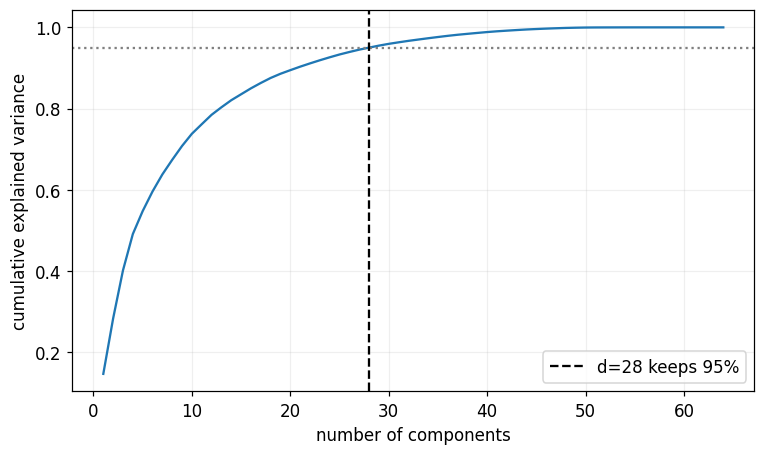

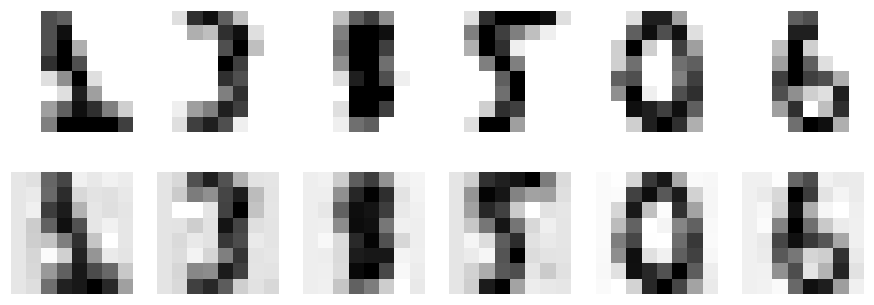

components for 95% variance: 28  of 64


In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
digits = load_digits()
Xtr, Xte, ytr, yte = train_test_split(digits.data, digits.target, test_size=.3, stratify=digits.target, random_state=SEED)

full = PCA(svd_solver='full').fit(Xtr)
cumvar = np.cumsum(full.explained_variance_ratio_)
d95 = int(np.argmax(cumvar >= 0.95) + 1)
plt.plot(np.arange(1, len(cumvar) + 1), cumvar)
plt.axhline(.95, ls=':', c='grey'); plt.axvline(d95, ls='--', c='k', label=f'd={d95} keeps 95%')
plt.xlabel('number of components'); plt.ylabel('cumulative explained variance'); plt.legend()
savefig('13_pca_scree')

pca = PCA(n_components=0.95, svd_solver='full').fit(Xtr)
Zte = pca.transform(Xte)
rebuilt = pca.inverse_transform(Zte)
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for k in range(6):
    axes[0, k].imshow(Xte[k].reshape(8, 8), cmap='binary'); axes[0, k].axis('off')
    axes[1, k].imshow(rebuilt[k].reshape(8, 8), cmap='binary'); axes[1, k].axis('off')
axes[0, 0].set_ylabel('original'); axes[1, 0].set_ylabel('rebuilt')
savefig('13_pca_reconstruction')
assert pca.n_components_ == d95
print('components for 95% variance:', d95, ' of', Xtr.shape[1])

## 5. 壓縮率與辨識品質：一起變好嗎？

對已切分的 digits，比較 2／10／30 主成分：解釋變異、重建 MSE、下游分類 CV 與時間。PCA 放在 CV 內每折重 fit。

In [6]:
import time
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
rows = []
for d in [2, 10, 30]:
    p = PCA(n_components=d, random_state=SEED).fit(Xtr)
    rebuilt = p.inverse_transform(p.transform(Xtr))
    clf = make_pipeline(PCA(n_components=d, random_state=SEED), StandardScaler(), LogisticRegression(max_iter=2000))
    t0 = time.perf_counter(); cv = cross_val_score(clf, Xtr, ytr, cv=5); sec = time.perf_counter() - t0
    rows.append({'components': d, 'explained_var': float(p.explained_variance_ratio_.sum()),
                 'reconstruction_MSE': float(np.mean((rebuilt - Xtr) ** 2)),
                 'classification_CV_acc': cv.mean(), 'cv_seconds': round(sec, 3)})
comp = pd.DataFrame(rows).set_index('components')
assert comp['reconstruction_MSE'].is_monotonic_decreasing
assert comp['classification_CV_acc'].is_monotonic_increasing
comp

,explained_var,reconstruction_MSE,classification_CV_acc,cv_seconds
components,,,,
2,0.282908,13.425941,0.604654,0.027
10,0.737825,4.908630,0.922039,0.023
30,0.959366,0.760785,0.955454,0.021


## 6. Swiss roll：PCA 攤不開彎曲流形，LLE 保留局部鄰近

PCA 找變異最大的平面投影；彎曲流形需要保留局部鄰居關係的方法，例如 LLE（教材圖 7-4、7-5、7-11）。

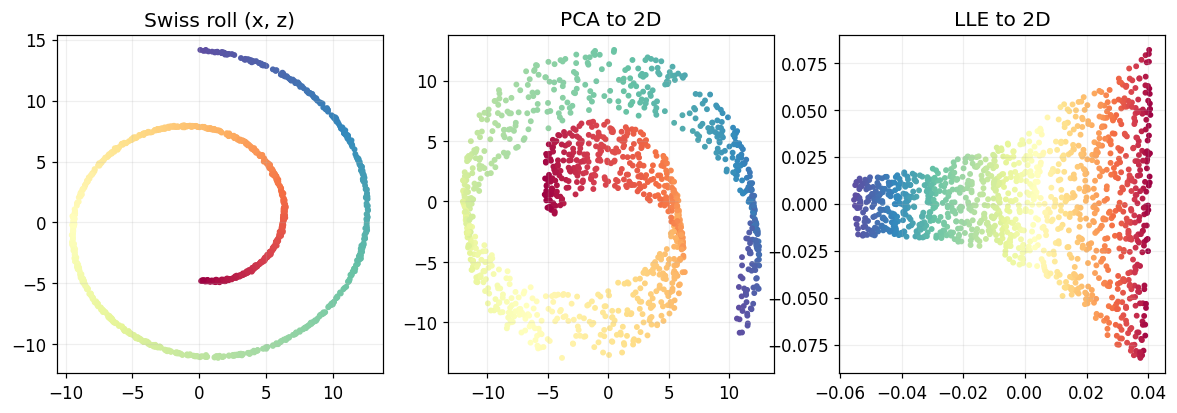

fraction of 10 nearest neighbors preserved: {'PCA': 0.394, 'LLE': 0.577}


In [7]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
Xsr, color = make_swiss_roll(n_samples=1200, noise=0.05, random_state=SEED)
pca2 = PCA(n_components=2, random_state=SEED).fit_transform(Xsr)
lle2 = LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=SEED).fit_transform(Xsr)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(Xsr[:, 0], Xsr[:, 2], c=color, cmap='Spectral', s=8); axes[0].set_title('Swiss roll (x, z)')
axes[1].scatter(pca2[:, 0], pca2[:, 1], c=color, cmap='Spectral', s=8); axes[1].set_title('PCA to 2D')
axes[2].scatter(lle2[:, 0], lle2[:, 1], c=color, cmap='Spectral', s=8); axes[2].set_title('LLE to 2D')
savefig('13_swiss_roll')

def neighbor_agreement(Z, k=10):
    from sklearn.neighbors import NearestNeighbors
    nn_hi = NearestNeighbors(n_neighbors=k + 1).fit(Xsr).kneighbors(return_distance=False)[:, 1:]
    nn_lo = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(return_distance=False)[:, 1:]
    return float(np.mean([len(set(a) & set(b)) / k for a, b in zip(nn_hi, nn_lo)]))
agree = {'PCA': neighbor_agreement(pca2), 'LLE': neighbor_agreement(lle2)}
assert agree['LLE'] > agree['PCA']            # LLE 較好保留局部鄰居
print('fraction of 10 nearest neighbors preserved:', {k: round(v, 3) for k, v in agree.items()})

## 7. 隨機投影與 Johnson–Lindenstrauss

不用先找主方向，隨機矩陣也能把高維點投到較低維而大致保距。JL 引理給出「保距所需最小維度」，只與樣本數與容忍度有關，不看原始維度。

In [8]:
from sklearn.random_projection import SparseRandomProjection, johnson_lindenstrauss_min_dim
rng = np.random.default_rng(SEED)
Xhi = rng.normal(size=(600, 4000))
eps = 0.2
k_min = int(johnson_lindenstrauss_min_dim(n_samples=600, eps=eps))
rp = SparseRandomProjection(n_components=k_min, random_state=SEED)
Xlo = rp.fit_transform(Xhi)
i, j = np.triu_indices(200, 1)
d_hi = np.linalg.norm(Xhi[:200][i] - Xhi[:200][j], axis=1)
d_lo = np.linalg.norm(Xlo[:200][i] - Xlo[:200][j], axis=1)
within = float(np.mean(np.abs(d_lo / d_hi - 1) <= eps))
report('dimensionality', {'curse': curse.to_dict(), 'first_PC': first_pc.tolist(),
       'digits_d95': d95, 'component_tradeoff': comp.to_dict(),
       'manifold_neighbor_agreement': agree, 'JL_min_dim': k_min, 'pairs_within_eps': within})
assert within > 0.9
print('JL min dim for n=600, eps=0.2:', k_min, ' | pairs within eps:', round(within, 3))

JL min dim for n=600, eps=0.2: 1476  | pairs within eps: 1.0


## 練習與參考答案

- 「最大變異」一定保留分類訊息嗎？**否，若標籤由小變異方向決定，PCA 可能丟掉關鍵訊息。**
- PCA 在什麼資料上操作？**中心化後的資料；`inverse_transform` 會把平均加回。**
- LDA 是無監督降維嗎？**否，它需要標籤。**
- 二維散點好看就代表模型較好嗎？**否，要用同一切分、同一分類器、把降維放進 CV 才比得準。**